# Earthquake Prediction using Machine Learning

## Base Imports

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading & Examining the Dataset

In [3]:
# Loading the dataset
df = pd.read_csv("earthquake_dataset(f).csv")

In [4]:
# View basic structure
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

# Show first few rows
df.head()

Shape of dataset: (19723, 22)

Column names:
['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource']


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-07-26T04:00:09.570Z,32.9118,76.1319,21.142,4.2,mb,21.0,171.0,5.591,0.49,...,2025-07-26T04:53:23.040Z,"39 km E of Bhadarwāh, India",earthquake,10.44,7.150,0.153,12.0,reviewed,us,us
1,2025-07-25T12:57:19.950Z,9.2223,93.6650,131.523,4.9,mb,97.0,64.0,5.132,0.74,...,2025-07-25T13:47:05.040Z,"288 km SSE of Port Blair, India",earthquake,10.04,5.393,0.056,99.0,reviewed,us,us
2,2025-07-21T18:00:59.115Z,11.0245,93.1986,110.568,4.5,mb,30.0,77.0,6.616,0.83,...,2025-07-21T18:58:00.040Z,"86 km SE of Port Blair, India",earthquake,12.29,7.999,0.113,23.0,reviewed,us,us
3,2025-07-21T11:41:14.079Z,36.7828,71.0564,248.083,4.0,mb,21.0,85.0,1.903,0.63,...,2025-07-22T07:43:18.040Z,"21 km ESE of Jurm, Afghanistan",earthquake,6.70,9.176,0.212,6.0,reviewed,us,us
4,2025-07-19T11:53:20.145Z,32.9687,89.9524,10.000,4.5,mb,56.0,133.0,3.407,0.77,...,2025-07-19T12:38:18.040Z,"258 km NW of Nagqu, China",earthquake,10.44,1.876,0.068,64.0,reviewed,us,us


## Initial Data Understanding

In [5]:
# Checking data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19723 entries, 0 to 19722
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             19723 non-null  object 
 1   latitude         19723 non-null  float64
 2   longitude        19723 non-null  float64
 3   depth            19723 non-null  float64
 4   mag              19723 non-null  float64
 5   magType          19723 non-null  object 
 6   nst              13344 non-null  float64
 7   gap              16880 non-null  float64
 8   dmin             7128 non-null   float64
 9   rms              19715 non-null  float64
 10  net              19723 non-null  object 
 11  id               19723 non-null  object 
 12  updated          19723 non-null  object 
 13  place            19723 non-null  object 
 14  type             19723 non-null  object 
 15  horizontalError  6470 non-null   float64
 16  depthError       11457 non-null  float64
 17  magError    

In [6]:
# Checking for missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
time                   0
latitude               0
longitude              0
depth                  0
mag                    0
magType                0
nst                 6379
gap                 2843
dmin               12595
rms                    8
net                    0
id                     0
updated                0
place                  0
type                   0
horizontalError    13253
depthError          8266
magError           12639
magNst              1450
status                 0
locationSource         0
magSource              0
dtype: int64


In [7]:
# Basic stats
print("\nStatistical summary:")
print(df.describe())


Statistical summary:
           latitude     longitude         depth          mag           nst  \
count  19723.000000  19723.000000  19723.000000  19723.00000  13344.000000   
mean      25.850936     82.962434     59.566576      4.37431     45.894934   
std       11.228030     10.635329     64.229222      0.47465     62.647766   
min        5.328000     64.347500      0.600000      2.60000      4.000000   
25%       13.111500     71.244400     10.000000      4.10000     15.000000   
50%       30.221000     85.448600     33.000000      4.30000     25.000000   
75%       36.149950     93.663000     89.613000      4.60000     48.000000   
max       37.440000     97.352100    400.570000      7.80000    728.000000   

                gap         dmin           rms  horizontalError    depthError  \
count  16880.000000  7128.000000  19715.000000      6470.000000  11457.000000   
mean     113.735581     2.957412      0.893924         7.724787      8.747830   
std       53.767196     2.346051

In [9]:
print("\nEvent types:", df['type'].unique())


Event types: ['earthquake']


In [10]:
print("Magnitude types:", df['magType'].unique())

Magnitude types: ['mb' 'mww' 'ml' 'mwr' 'mwb' 'mb_lg' 'mwc' 'mw' 'Mb' 'ms' 'md']


## Data Cleaning

In [16]:
# Dropping columns not useful for magnitude prediction
columns_to_drop = ['place', 'type', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 
                   'horizontalError', 'depthError', 'magError', 'magNst', 'status', 
                   'locationSource', 'magSource', 'id', 'updated']

df = df.drop(columns=columns_to_drop, errors='ignore')

In [17]:
# Dropping rows with missing values in key columns
df = df.dropna(subset=['mag', 'latitude', 'longitude', 'depth', 'time'])

In [18]:
# Resetting index after dropping
df = df.reset_index(drop=True)

In [19]:
# Confirming the shape and remaining columns
print("Shape after cleaning:", df.shape)
print("Remaining columns:", df.columns.tolist())

Shape after cleaning: (19723, 5)
Remaining columns: ['time', 'latitude', 'longitude', 'depth', 'mag']


In [15]:
# Checking for outliers or invalid entries
print("Magnitude range:", df['mag'].min(), "to", df['mag'].max())
print("Depth range:", df['depth'].min(), "to", df['depth'].max())

Magnitude range: 2.6 to 7.8
Depth range: 0.6 to 400.57


In [20]:
df.head()

,time,latitude,longitude,depth,mag
0,2025-07-26T04:00:09.570Z,32.9118,76.1319,21.142,4.2
1,2025-07-25T12:57:19.950Z,9.2223,93.6650,131.523,4.9
2,2025-07-21T18:00:59.115Z,11.0245,93.1986,110.568,4.5
3,2025-07-21T11:41:14.079Z,36.7828,71.0564,248.083,4.0
4,2025-07-19T11:53:20.145Z,32.9687,89.9524,10.000,4.5


In [21]:
# Date time format
df['time'] = pd.to_datetime(df['time'], errors='coerce')

In [22]:
print(df['time'].dtype)

datetime64[ns, UTC]


## Date-Time Format

In [23]:
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['day'] = df['time'].dt.day
df['hour'] = df['time'].dt.hour
df['weekday'] = df['time'].dt.weekday

In [24]:
df.head()

,time,latitude,longitude,depth,mag,year,month,day,hour,weekday
0,2025-07-26 04:00:09.570000+00:00,32.9118,76.1319,21.142,4.2,2025,7,26,4,5
1,2025-07-25 12:57:19.950000+00:00,9.2223,93.6650,131.523,4.9,2025,7,25,12,4
2,2025-07-21 18:00:59.115000+00:00,11.0245,93.1986,110.568,4.5,2025,7,21,18,0
3,2025-07-21 11:41:14.079000+00:00,36.7828,71.0564,248.083,4.0,2025,7,21,11,0
4,2025-07-19 11:53:20.145000+00:00,32.9687,89.9524,10.000,4.5,2025,7,19,11,5


## Exploratory Data Analysis (EDA)

In [25]:
print("Dataset shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nSummary statistics:\n", df.describe())

Dataset shape: (19723, 10)

Column names:
 ['time', 'latitude', 'longitude', 'depth', 'mag', 'year', 'month', 'day', 'hour', 'weekday']

Data types:
 time         datetime64[ns, UTC]
latitude                 float64
longitude                float64
depth                    float64
mag                      float64
year                       int32
month                      int32
day                        int32
hour                       int32
weekday                    int32
dtype: object

Missing values:
 time         0
latitude     0
longitude    0
depth        0
mag          0
year         0
month        0
day          0
hour         0
weekday      0
dtype: int64

Summary statistics:
            latitude     longitude         depth          mag          year  \
count  19723.000000  19723.000000  19723.000000  19723.00000  19723.000000   
mean      25.850936     82.962434     59.566576      4.37431   2010.185367   
std       11.228030     10.635329     64.229222      0.47465      7.5

Goal of EDA (Exploratory Data Analysis)

EDA helps us understand the structure, patterns, relationships, and anomalies in our data before modeling.

We're trying to answer:
- What does each variable look like? (Univariate analysis)
- How do variables relate to each other? (Bivariate/multivariate analysis)
- Are there any patterns over time?
- Are there outliers or noise?

### Univariate Analysis

(individual feature distributions)

#### 1. mag (Earthquake Magnitude)

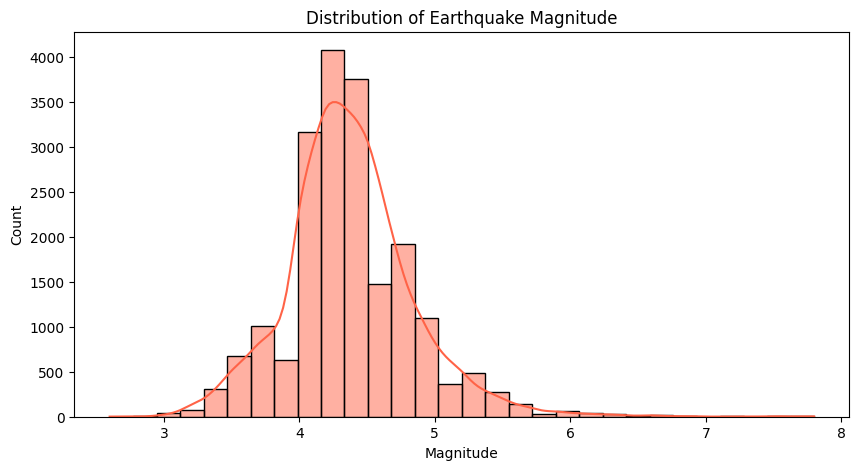

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(df['mag'], bins=30, kde=True, color='tomato')
plt.title('Distribution of Earthquake Magnitude')
plt.xlabel('Magnitude')
plt.ylabel('Count')
plt.show()

#### 2. depth (Depth in km)

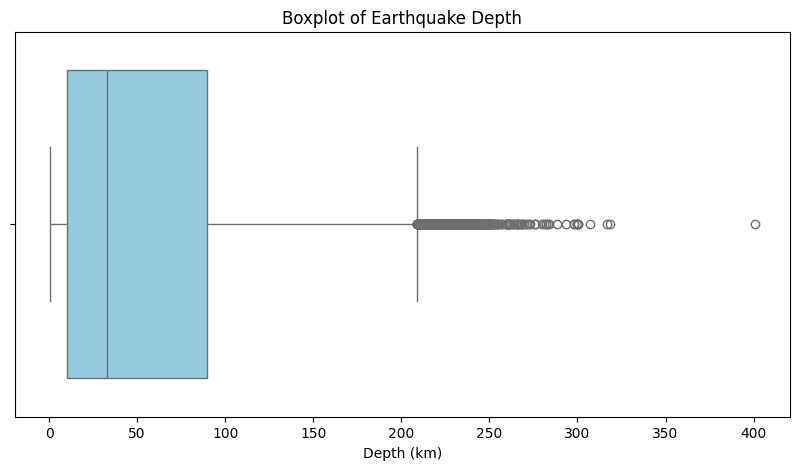

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['depth'], color='skyblue')
plt.title('Boxplot of Earthquake Depth')
plt.xlabel('Depth (km)')
plt.show()

#### 3. year, month, hour, weekday

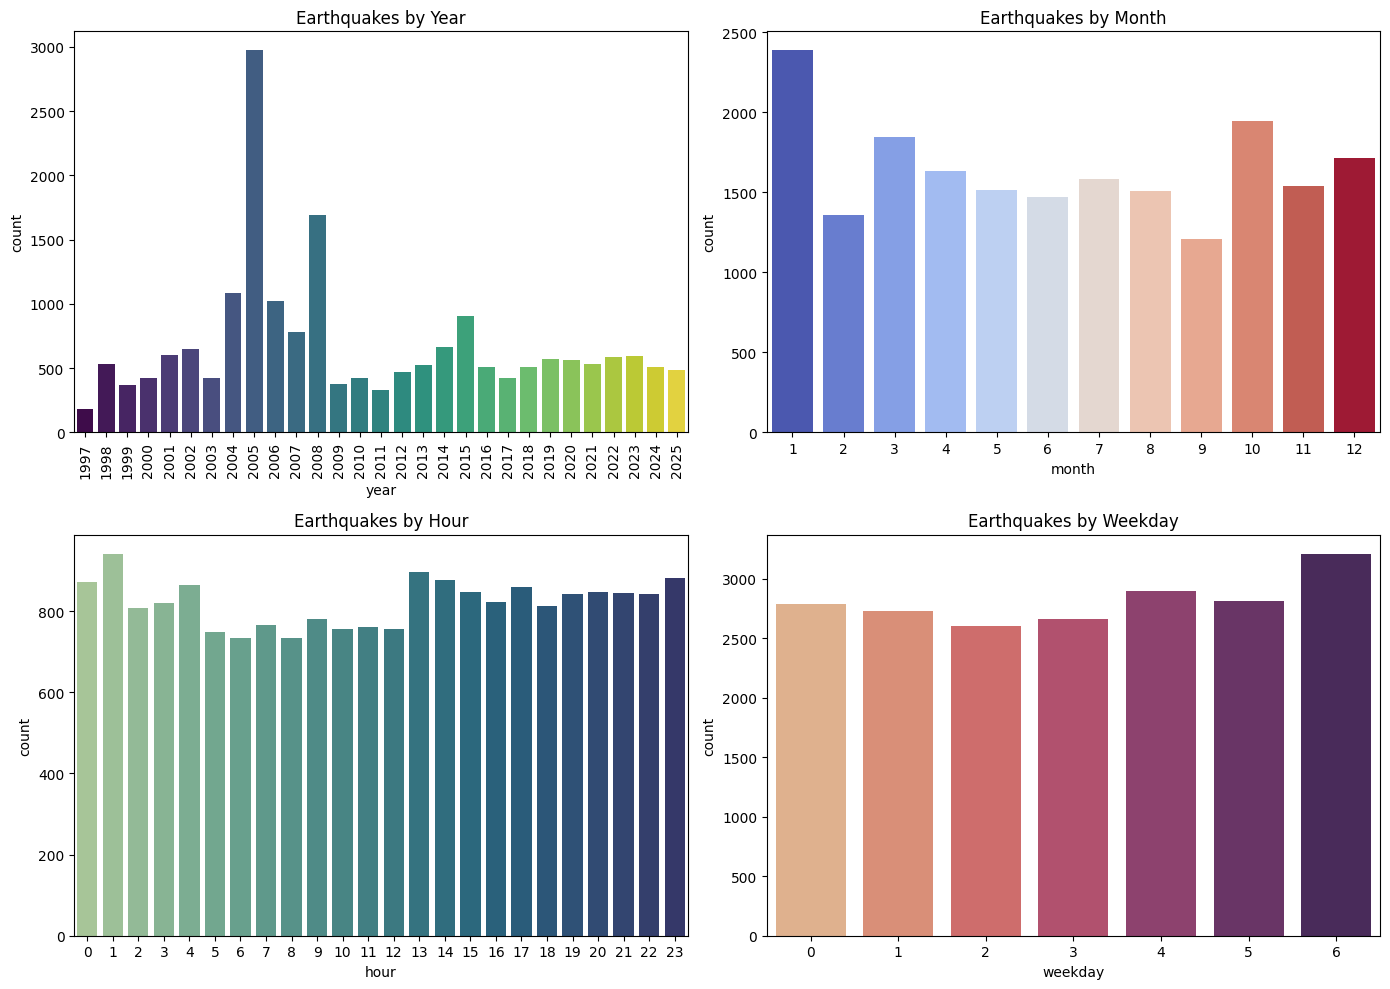

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.countplot(ax=axes[0,0], x='year', hue='year', data=df, palette='viridis', legend=False)
axes[0,0].set_title("Earthquakes by Year")
axes[0,0].tick_params(axis='x', rotation=90)

sns.countplot(ax=axes[0,1], x='month', hue='month', data=df, palette='coolwarm', legend=False)
axes[0,1].set_title("Earthquakes by Month")

sns.countplot(ax=axes[1,0], x='hour', hue='hour', data=df, palette='crest', legend=False)
axes[1,0].set_title("Earthquakes by Hour")

sns.countplot(ax=axes[1,1], x='weekday', hue='weekday', data=df, palette='flare', legend=False)
axes[1,1].set_title("Earthquakes by Weekday")

plt.tight_layout()
plt.show()

#### 4. latitude & longitude

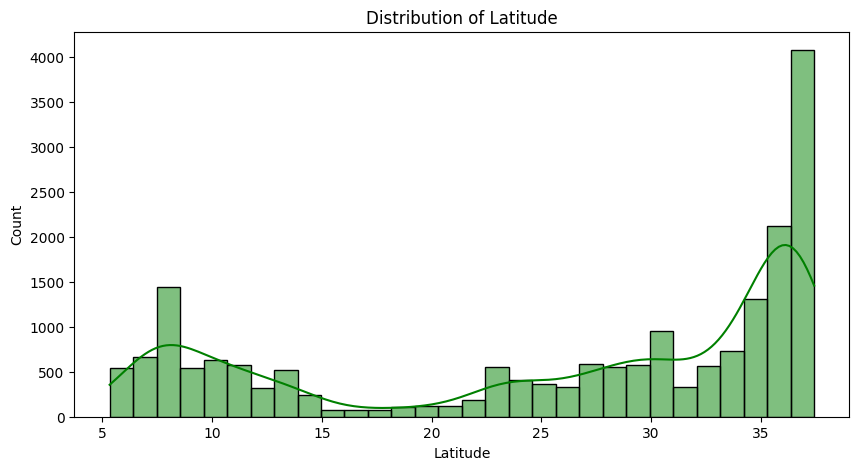

In [31]:
# Latitude
plt.figure(figsize=(10, 5))
sns.histplot(df['latitude'], bins=30, kde=True, color='green')
plt.title('Distribution of Latitude')
plt.xlabel('Latitude')
plt.ylabel('Count')
plt.show()

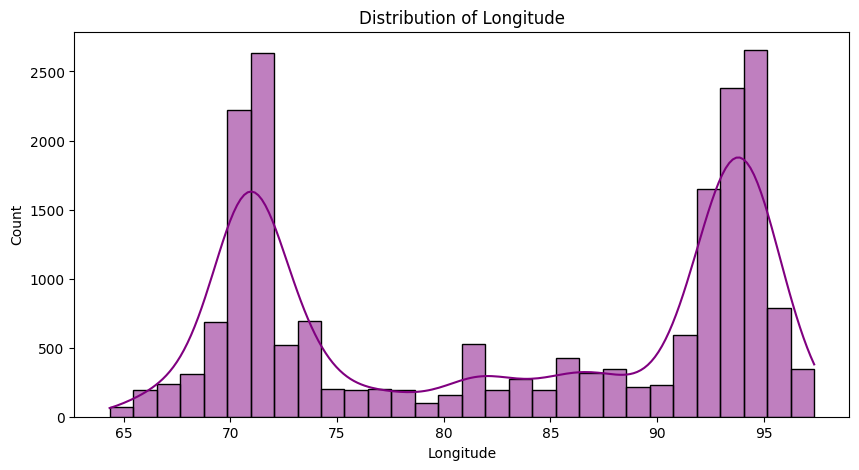

In [32]:
# Longitude
plt.figure(figsize=(10, 5))
sns.histplot(df['longitude'], bins=30, kde=True, color='purple')
plt.title('Distribution of Longitude')
plt.xlabel('Longitude')
plt.ylabel('Count')
plt.show()

These plots will help us understand if:
- Earthquakes are clustered in specific lat-long ranges (e.g., near Himalayas, Assam, etc.)
- Data is concentrated in a narrow band or spread out.

#### 5. day

It helps count how often quakes occurred on different days of the month

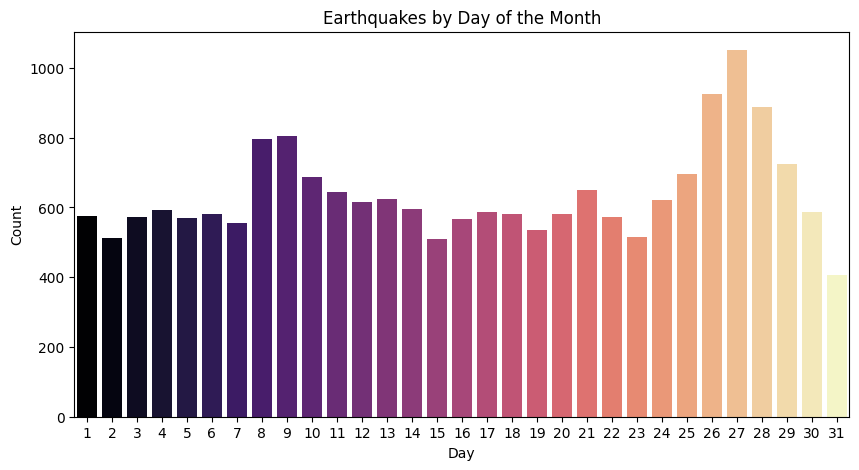

In [34]:
plt.figure(figsize=(10,5))
sns.countplot(x='day', hue='day', data=df, palette='magma', legend=False)
plt.title('Earthquakes by Day of the Month')
plt.xlabel('Day')
plt.ylabel('Count')
plt.show()

#### 6. mag – Distribution with KDE + Rug (for precision)

This shows the density more smoothly with fine detail

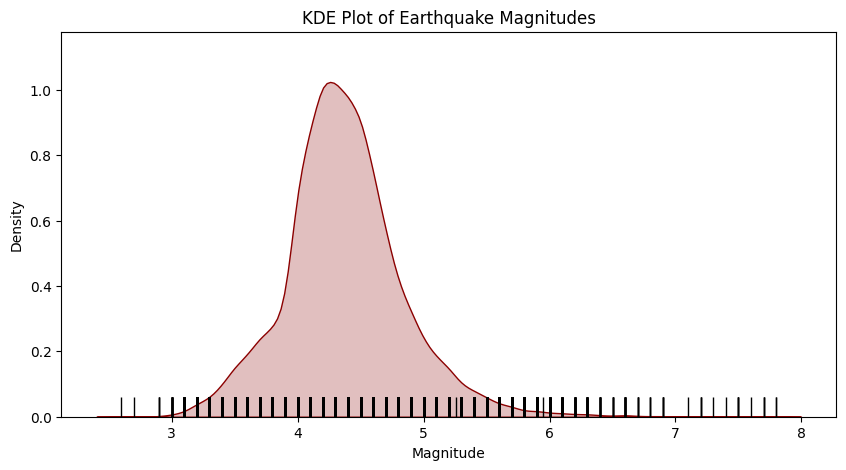

In [36]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df['mag'], fill=True, color='darkred')
sns.rugplot(df['mag'], height=0.05, color='black')
plt.title('KDE Plot of Earthquake Magnitudes')
plt.xlabel('Magnitude')
plt.ylabel('Density')
plt.show()

#### 7. depth – Violin Plot (combines box + KDE)

- Helps spot skewness.
- Shows where depth values are densely packed.

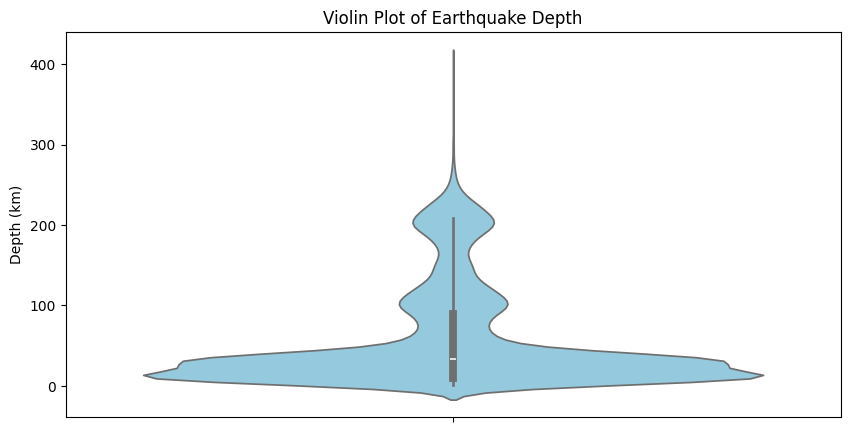

In [37]:
plt.figure(figsize=(10, 5))
sns.violinplot(y='depth', data=df, color='skyblue')
plt.title('Violin Plot of Earthquake Depth')
plt.ylabel('Depth (km)')
plt.show()

#### 9. Frequency Table for weekday

In [38]:
df['weekday'].value_counts().sort_index()

weekday
0    2792
1    2730
2    2608
3    2665
4    2899
5    2817
6    3212
Name: count, dtype: int64

In [40]:
import calendar
df['weekday_name'] = df['weekday'].apply(lambda x: calendar.day_name[x])
df['weekday_name'].value_counts().sort_index()

weekday_name
Friday       2899
Monday       2792
Saturday     2817
Sunday       3212
Thursday     2665
Tuesday      2730
Wednesday    2608
Name: count, dtype: int64

### Bivariate Analysis

It means analyzing relationships between two variables.
We’ll explore:
- Numerical vs Numerical (e.g., depth vs mag)
- Categorical vs Numerical (e.g., month vs mag)
- Geographical Relationships (latitude vs longitude)

#### 1. Depth vs Magnitude

To check if deeper earthquakes are stronger (positive correlation?) or weaker (negative?)

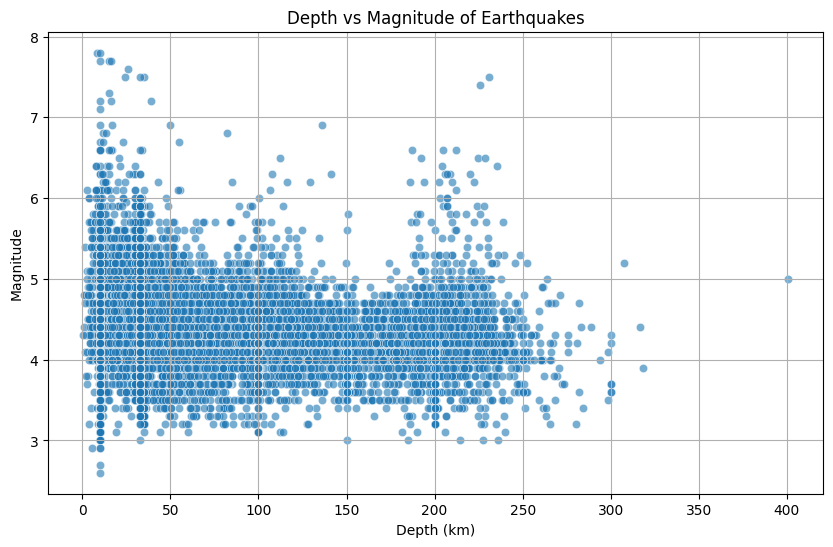

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='depth', y='mag', data=df, alpha=0.6)
plt.title('Depth vs Magnitude of Earthquakes')
plt.xlabel('Depth (km)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

#### 2. Correlation Matrix

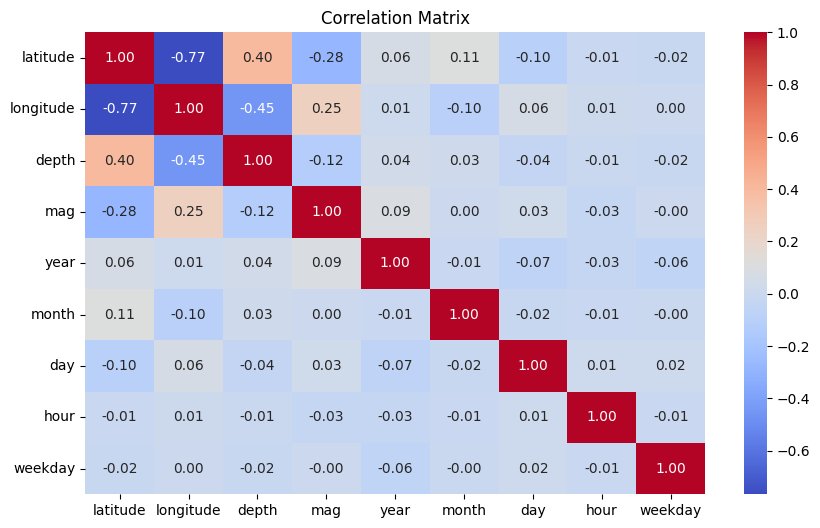

In [46]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

#### 3. Year vs Magnitude

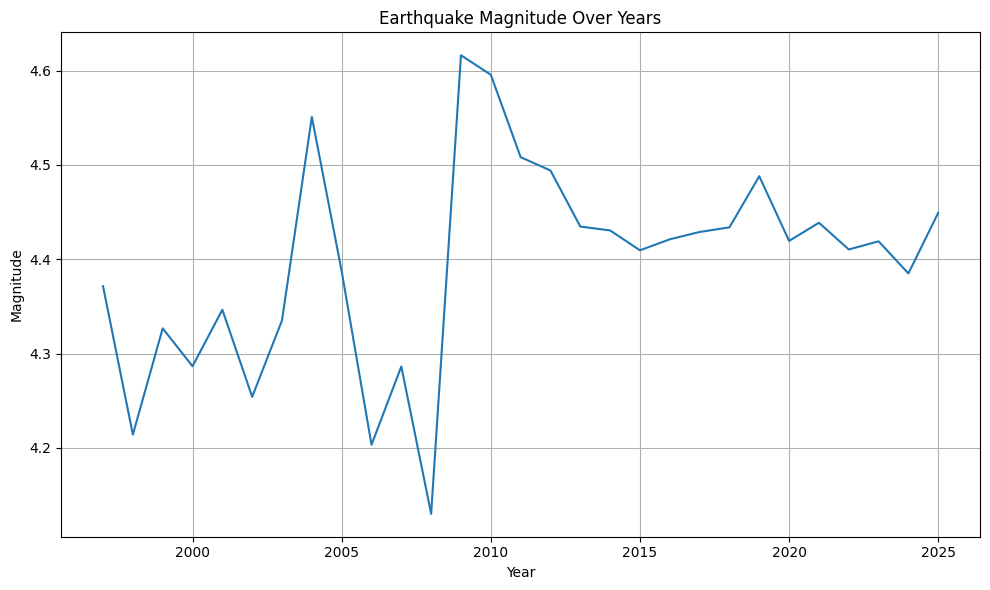

In [58]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='year', y='mag', errorbar=None)
plt.title('Earthquake Magnitude Over Years')
plt.xlabel('Year')
plt.ylabel('Magnitude')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4. Month vs Magnitude

To check seasonal patterns (are magnitudes higher in certain months?)

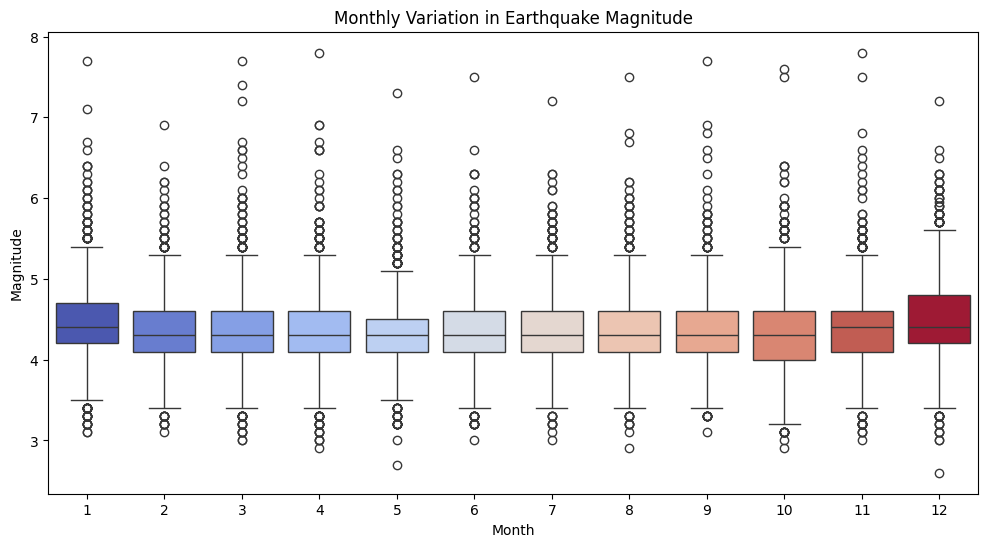

In [48]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', hue='month', y='mag', data=df, palette='coolwarm', legend=False)
plt.title('Monthly Variation in Earthquake Magnitude')
plt.xlabel('Month')
plt.ylabel('Magnitude')
plt.show()

#### 5. Weekday vs Magnitude

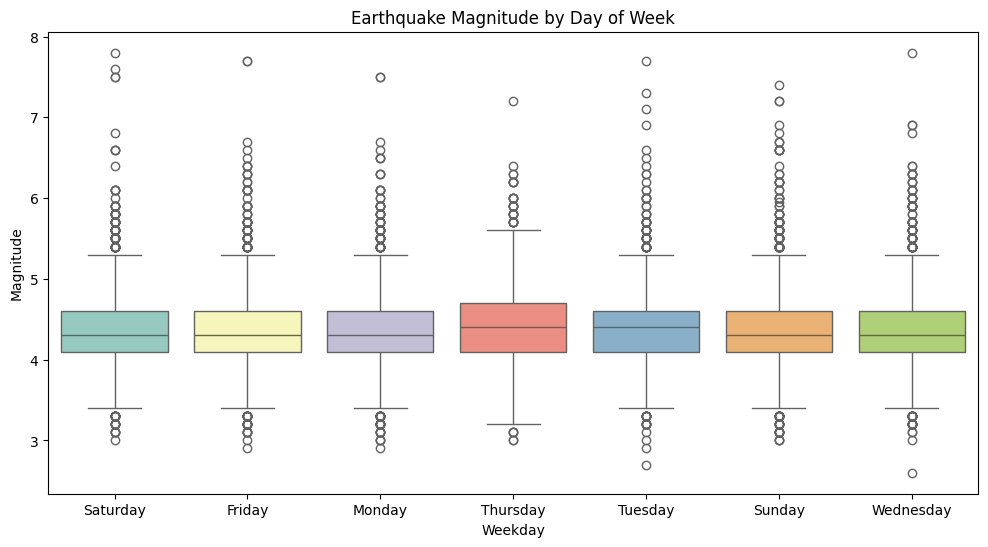

In [50]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='weekday_name', hue='weekday_name', y='mag', data=df, palette='Set3', legend=False)
plt.title('Earthquake Magnitude by Day of Week')
plt.xlabel('Weekday')
plt.ylabel('Magnitude')
plt.show()

#### 6. Hour vs Magnitude 

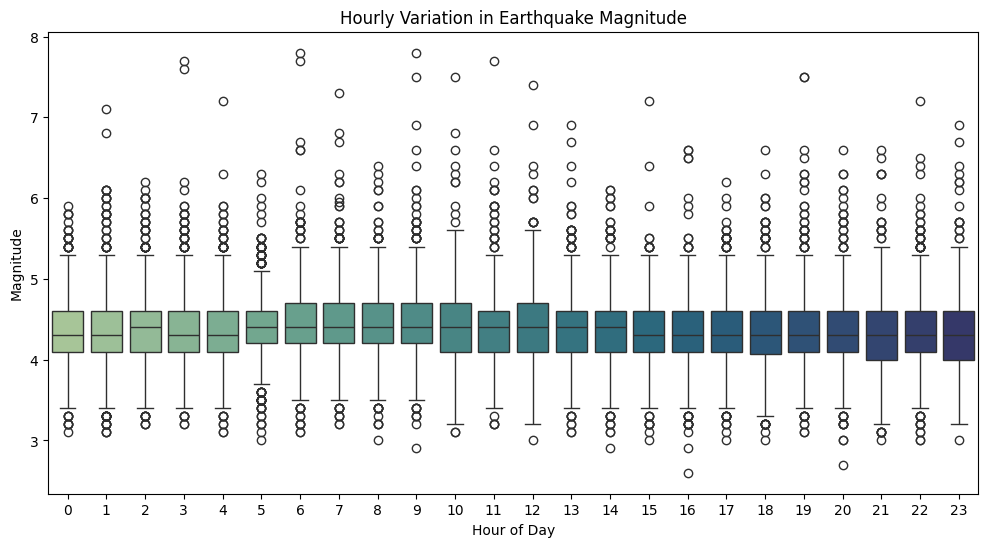

In [52]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='hour', hue='hour', y='mag', data=df, palette='crest', legend=False)
plt.title('Hourly Variation in Earthquake Magnitude')
plt.xlabel('Hour of Day')
plt.ylabel('Magnitude')
plt.show()

#### 7. Latitude vs Longitude

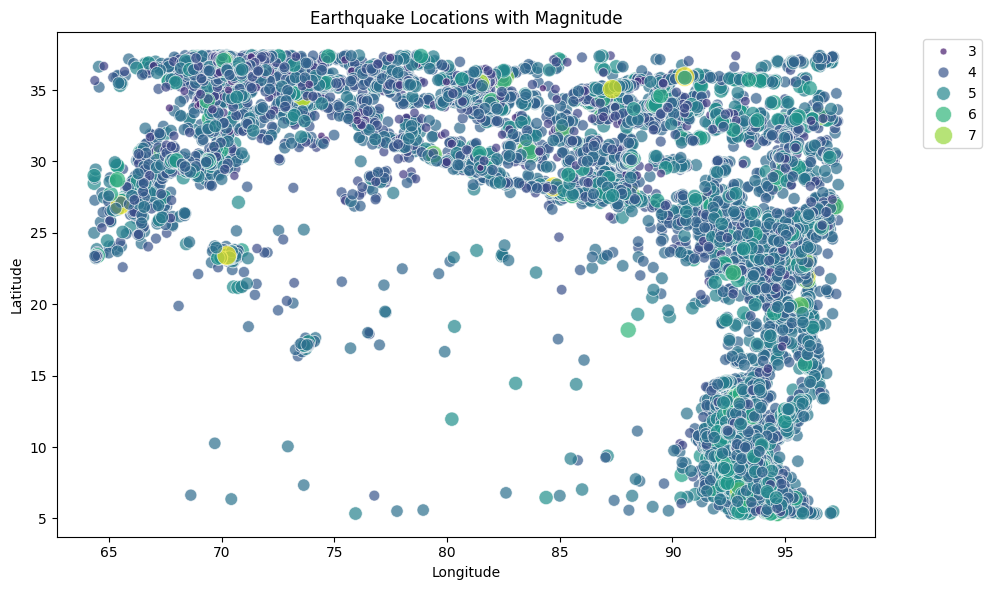

In [56]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, x='longitude', y='latitude', hue='mag', palette='viridis', size='mag', sizes=(10, 200), alpha=0.7
)
plt.title('Earthquake Locations with Magnitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 8. Pairplot for Key Features

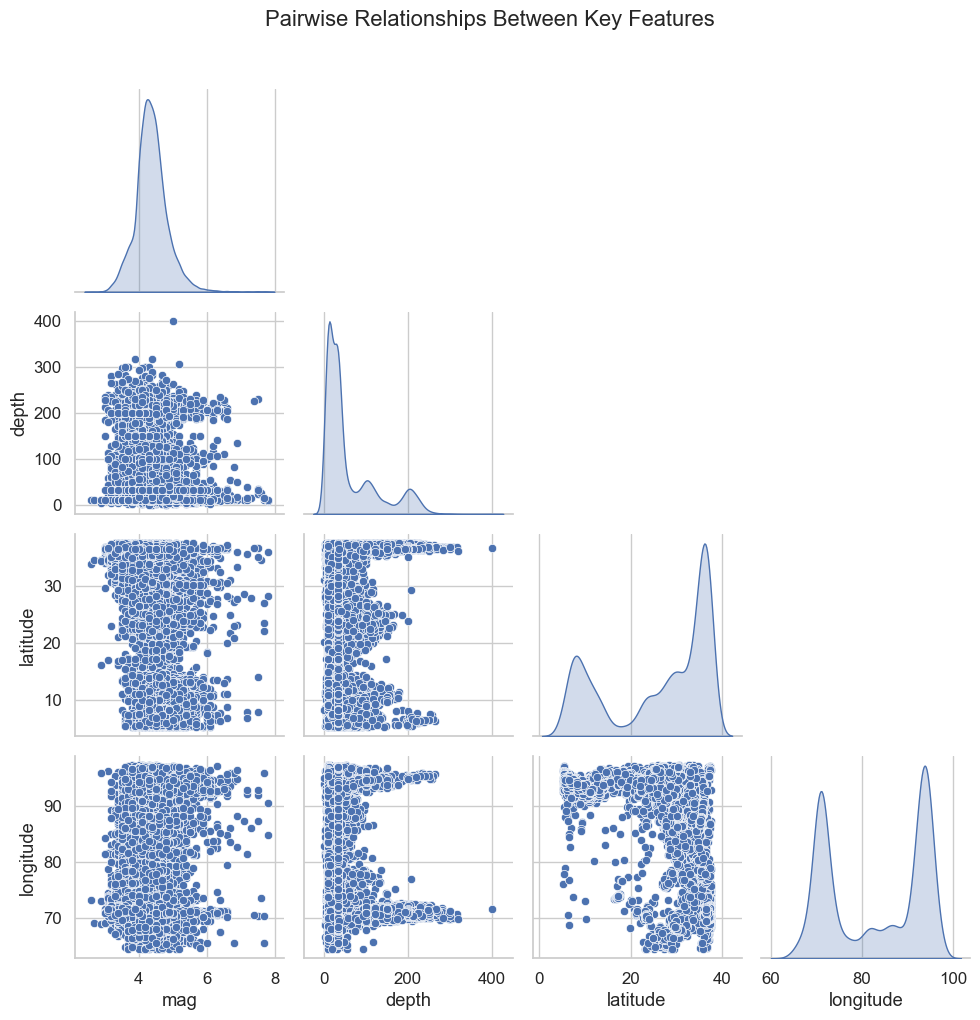

In [62]:
selected_cols = ['mag', 'depth', 'latitude', 'longitude']
sns.pairplot(df[selected_cols], corner=True, diag_kind='kde')
plt.suptitle('Pairwise Relationships Between Key Features', y=1.02)
plt.tight_layout()
plt.show()

### Multivariate Analysis

It helps us:
- Understand how multiple features together influence earthquake magnitude.
- Reveal hidden interactions between location, depth, and time.
- Prepare better features for machine learning models.

#### 3D Scatter Plot: Depth vs Latitude vs Magnitude

It helps visualize how magnitude changes across depth and location.

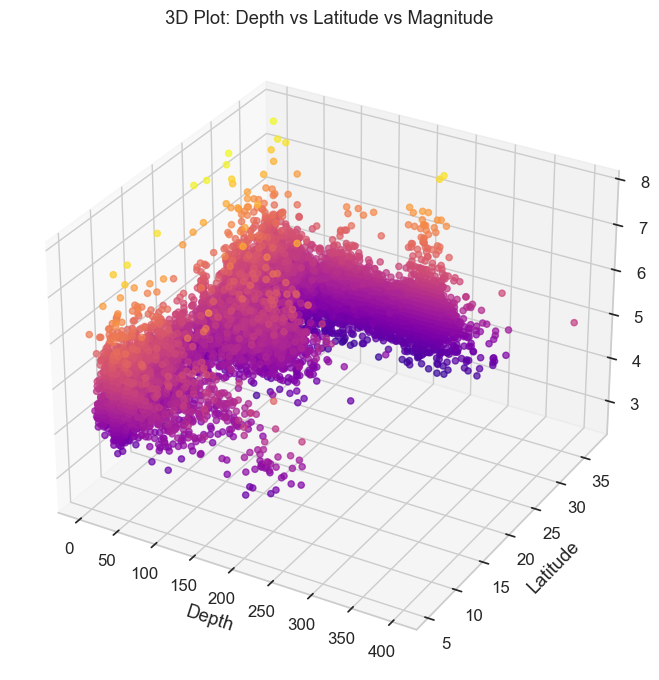

In [64]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['depth'], df['latitude'], df['mag'], c=df['mag'], cmap='plasma', alpha=0.7)
ax.set_xlabel('Depth')
ax.set_ylabel('Latitude')
ax.set_zlabel('Magnitude')
plt.title('3D Plot: Depth vs Latitude vs Magnitude')
plt.tight_layout()
plt.show()

#### FacetGrid: Magnitude Distribution by Month & Hour

It helps see how magnitude behaves across two time-based dimensions.

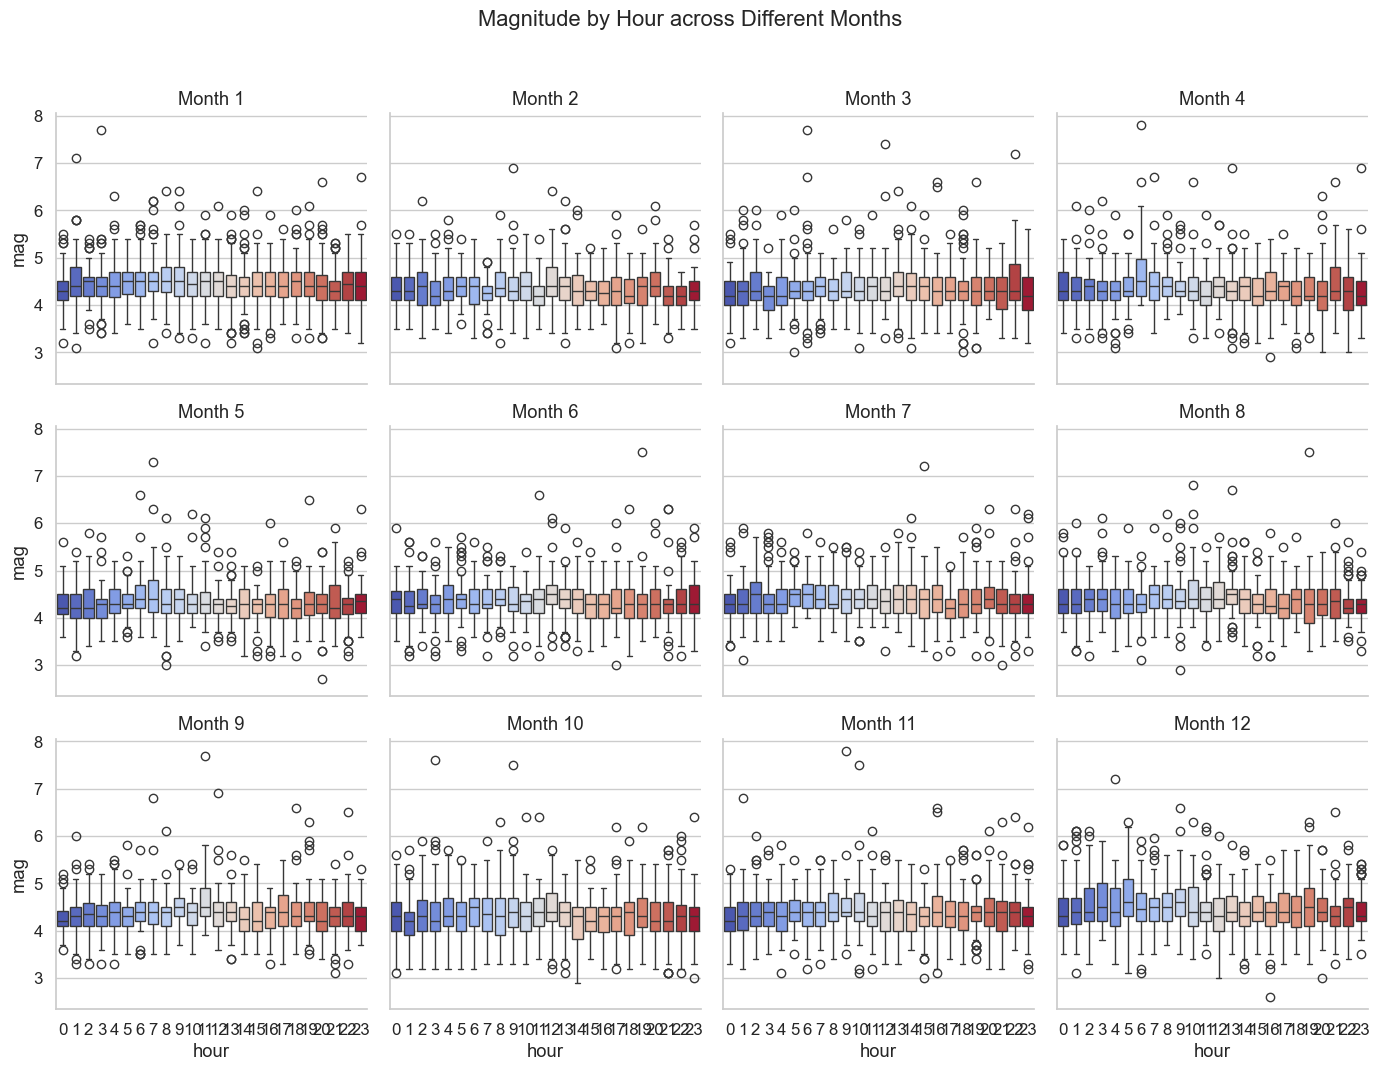

In [66]:
g = sns.FacetGrid(df, col="month", col_wrap=4, height=3.5)
g.map_dataframe(sns.boxplot, x="hour", hue="hour", y="mag", palette='coolwarm', legend=False)
g.set_titles(col_template="Month {col_name}")
g.fig.suptitle("Magnitude by Hour across Different Months", y=1.02)
plt.tight_layout()
plt.show()

#### Grouped Violin Plot: Month vs Magnitude (grouped by year bins)

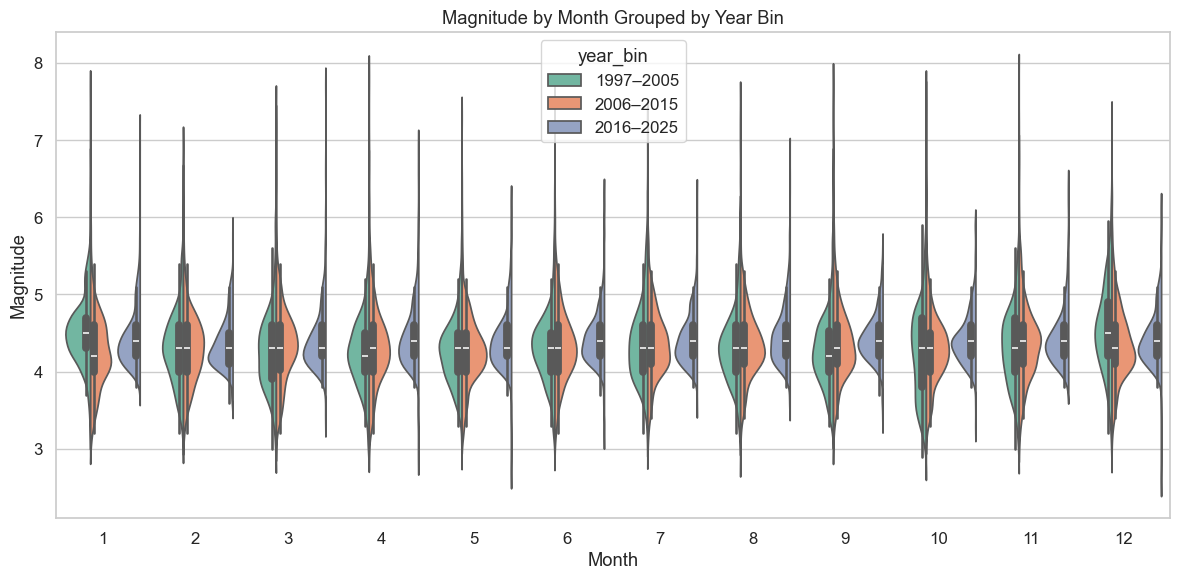

In [67]:
df['year_bin'] = pd.cut(df['year'], bins=[1996, 2005, 2015, 2025], labels=['1997–2005', '2006–2015', '2016–2025'])

plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='month', y='mag', hue='year_bin', palette='Set2', split=True)
plt.title('Magnitude by Month Grouped by Year Bin')
plt.xlabel('Month')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

#### Depth vs Longitude Colored by Magnitude

To observe if deeper quakes are concentrated in certain longitudes and if they’re stronger.

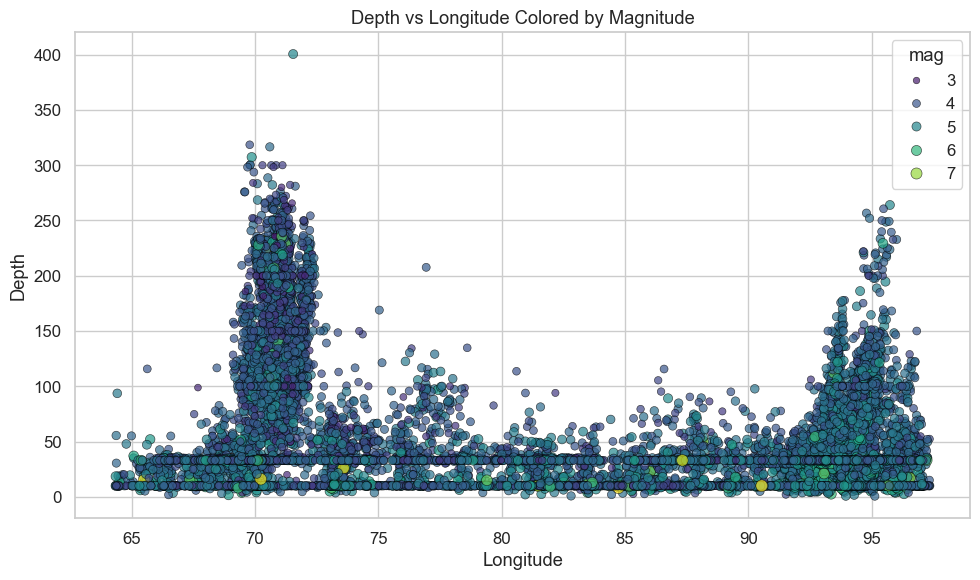

In [69]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='longitude', y='depth', hue='mag', size='mag',
                palette='viridis', alpha=0.7, edgecolor='black')
plt.title('Depth vs Longitude Colored by Magnitude')
plt.xlabel('Longitude')
plt.ylabel('Depth')
plt.tight_layout()
plt.show()

#### Depth vs Latitude Colored by Magnitude

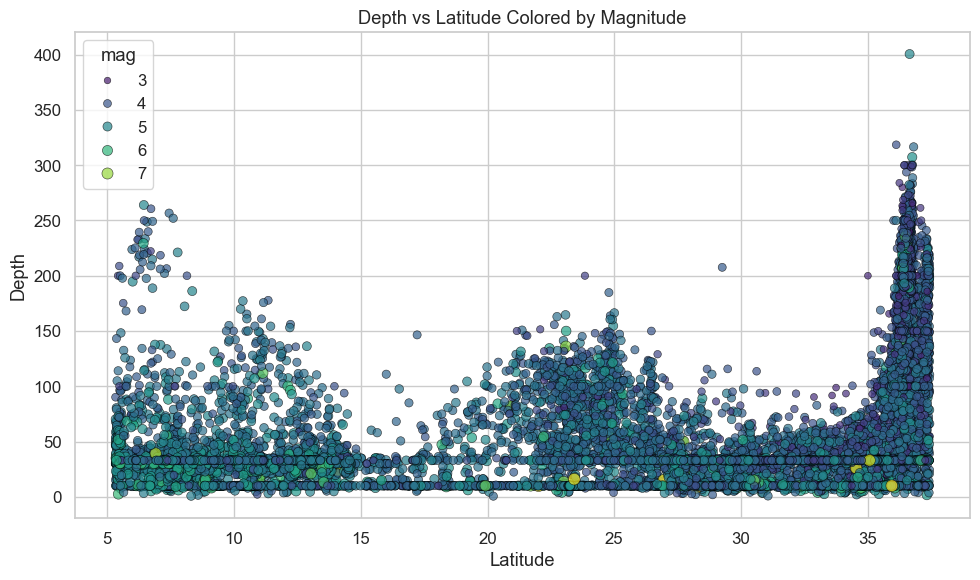

In [70]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='latitude', y='depth', hue='mag', size='mag',
                palette='viridis', alpha=0.7, edgecolor='black')
plt.title('Depth vs Latitude Colored by Magnitude')
plt.xlabel('Latitude')
plt.ylabel('Depth')
plt.tight_layout()
plt.show()

### Feature Selection

In [72]:
X = df[['latitude', 'longitude', 'depth', 'year', 'month', 'day', 'hour', 'weekday']]
y = df['mag']

### Train-Test Split

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

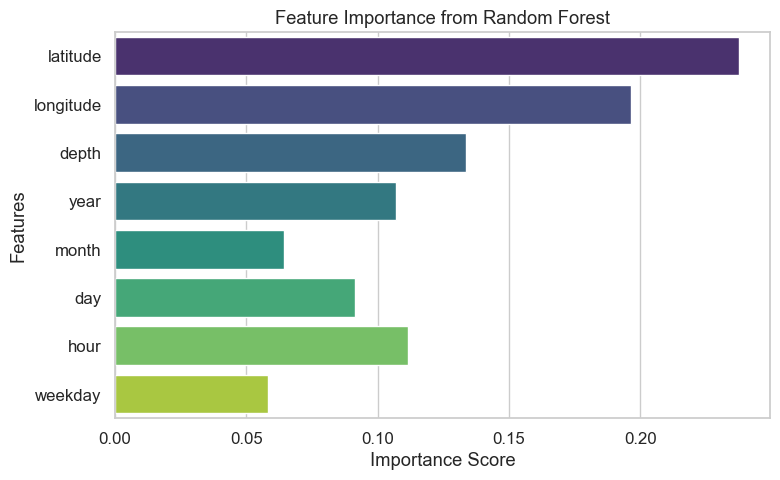

In [75]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature importance
importances = rf.feature_importances_
features = X.columns

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features, hue=features, palette='viridis', legend=False)
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [76]:
import pandas as pd

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

     Feature  Importance
0   latitude    0.237662
1  longitude    0.196322
2      depth    0.133568
6       hour    0.111674
3       year    0.107136
5        day    0.091190
4      month    0.064278
7    weekday    0.058170


####  Retraining with Top 3 Features (latitude, longitude, depth)

In [77]:
top3 = ['latitude', 'longitude', 'depth']
X_top3 = df[top3]

X_train_top3, X_test_top3, y_train, y_test = train_test_split(X_top3, y, test_size=0.2, random_state=42)

rf_top3 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_top3.fit(X_train_top3, y_train)

y_pred_top3 = rf_top3.predict(X_test_top3)

from sklearn.metrics import r2_score, mean_squared_error
print("R² Score (Top 3):", r2_score(y_test, y_pred_top3))
print("MSE (Top 3):", mean_squared_error(y_test, y_pred_top3))

R² Score (Top 3): 0.08903986234145522
MSE (Top 3): 0.19970806594930293


#### Retraining with Top 5 Features (latitude, longitude, depth, hour, year)

In [78]:
top5 = ['latitude', 'longitude', 'depth', 'hour', 'year']
X_top5 = df[top5]

X_train_top5, X_test_top5, y_train, y_test = train_test_split(X_top5, y, test_size=0.2, random_state=42)

rf_top5 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_top5.fit(X_train_top5, y_train)

y_pred_top5 = rf_top5.predict(X_test_top5)

print("R² Score (Top 5):", r2_score(y_test, y_pred_top5))
print("MSE (Top 5):", mean_squared_error(y_test, y_pred_top5))

R² Score (Top 5): 0.1774236041963272
MSE (Top 5): 0.18033186558935366


#### Retraining with All Features

In [79]:
rf_all = RandomForestRegressor(n_estimators=100, random_state=42)
rf_all.fit(X_train, y_train)
y_pred_all = rf_all.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error
print("R² Score (All):", r2_score(y_test, y_pred_all))
print("MSE (All):", mean_squared_error(y_test, y_pred_all))

R² Score (All): 0.2078961254618129
MSE (All): 0.17365143245627376


### Hyperparameter Tuning using GridSearchCV for Random Forest Regressor

In [80]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

In [81]:
# Defining the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2],
    'min_samples_leaf': [1, 2]
}

In [82]:
# Initializing the Random Forest model
rf_model = RandomForestRegressor(random_state=42)

In [83]:
# Setting up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

In [84]:
# Fitting on training data
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, None], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2], 'n_estimators': [100, 200]},
             scoring='r2', verbose=1)

In [85]:
# Best model
best_rf = grid_search.best_estimator_

In [86]:
# Prediction and evaluation
y_pred = best_rf.predict(X_test)
print("Best Parameters:", grid_search.best_params_)
print("R² Score (Tuned RF):", r2_score(y_test, y_pred))
print("MSE (Tuned RF):", mean_squared_error(y_test, y_pred))

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
R² Score (Tuned RF): 0.2199583499638036
MSE (Tuned RF): 0.17100705382020023


### Training with other models

#### Model 1: Gradient Boosting Regressor (GBR)

In [87]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Initialize and fit the model
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

# Predict
y_pred_gbr = gbr.predict(X_test)

# Evaluate
print("R² Score (GBR):", r2_score(y_test, y_pred_gbr))
print("MSE (GBR):", mean_squared_error(y_test, y_pred_gbr))

R² Score (GBR): 0.19295987716093033
MSE (GBR): 0.176925877887415


#### Model 2: XGBoost Regressor

In [89]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Initialize and fit XGBoost
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test)

# Evaluate
print("R² Score (XGBoost):", r2_score(y_test, y_pred_xgb))
print("MSE (XGBoost):", mean_squared_error(y_test, y_pred_xgb))

R² Score (XGBoost): 0.19970190636532237
MSE (XGBoost): 0.1754478355919051


#### Model 3: LightGBM Regressor

In [91]:
pip install lightgbm


  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)


In [92]:
from lightgbm import LGBMRegressor

# Initialize and fit the model
lgbm = LGBMRegressor(random_state=42)
lgbm.fit(X_train, y_train)

# Predict
y_pred_lgbm = lgbm.predict(X_test)

# Evaluate
print("R² Score (LightGBM):", r2_score(y_test, y_pred_lgbm))
print("MSE (LightGBM):", mean_squared_error(y_test, y_pred_lgbm))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001976 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 871
[LightGBM] [Info] Number of data points in the train set: 15778, number of used features: 8
[LightGBM] [Info] Start training from score 4.374890
R² Score (LightGBM): 0.2314105589573433
MSE (LightGBM): 0.16849640772889532


#### Model 4: Support Vector Regression (SVR)

In [93]:
# Scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [94]:
# Run SVR
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

print("R² Score (SVR):", r2_score(y_test, y_pred_svr))
print("MSE (SVR):", mean_squared_error(y_test, y_pred_svr))

R² Score (SVR): 0.11229198249075412
MSE (SVR): 0.19461054768009203


#### Model 5: Linear Regression

In [95]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("R² Score (Linear Regression):", r2_score(y_test, y_pred_lr))
print("MSE (Linear Regression):", mean_squared_error(y_test, y_pred_lr))

R² Score (Linear Regression): 0.0829061467370571
MSE (Linear Regression): 0.2010527488062125


Final Model Performance Comparison:

| Model                       | R² Score  | MSE       | Remarks                                  |
| --------------------------- | --------- | --------- | ---------------------------------------- |
| **LightGBM**                | **0.231** | **0.168** | Best performer                           |
| Random Forest (Tuned)       | 0.220     | 0.171     | Strong performance                       |
| XGBoost                     | 0.200     | 0.175     | Competitive model                        |
| Gradient Boosting Regressor | 0.193     | 0.177     | Moderate                                 |
| SVR                         | 0.112     | 0.195     | Underperformed (not ideal for this case) |
| Linear Regression           | 0.083     | 0.201     | Too simplistic for this data             |

### Finalizing the Model - LightGBM

In [97]:
import joblib

# Saving the trained LightGBM model
joblib.dump(lgbm, 'lightgbm_earthquake_model.pkl')

['lightgbm_earthquake_model.pkl']

In [98]:
# Load the saved model
loaded_model = joblib.load('lightgbm_earthquake_model.pkl')

# Use it to predict
y_pred_loaded = loaded_model.predict(X_test)

#### Visualizing and Evaluating Model Performance Further

##### 1. Predicted vs Actual Plot

Visualizes how well the predicted magnitudes match actual magnitudes.

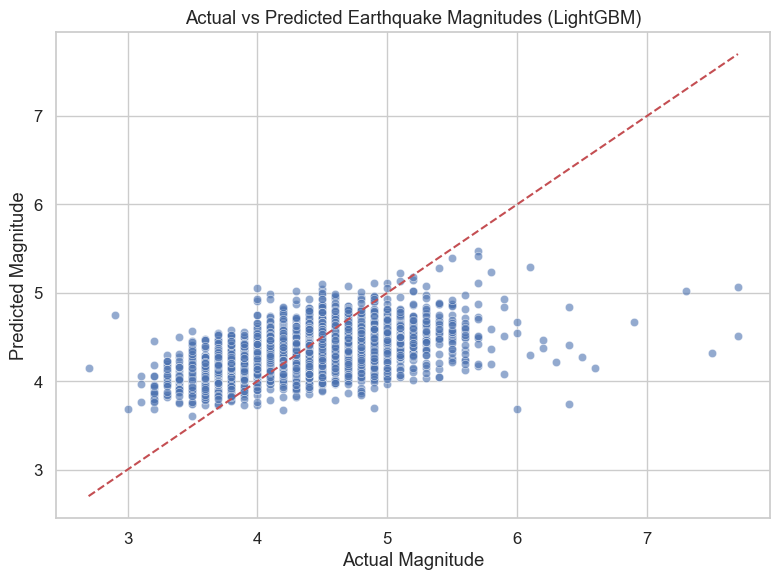

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_lgbm, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # 45-degree line
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Actual vs Predicted Earthquake Magnitudes (LightGBM)')
plt.tight_layout()
plt.show()

##### 2. Residual Plot

Shows errors (residuals) between predictions and actual values.

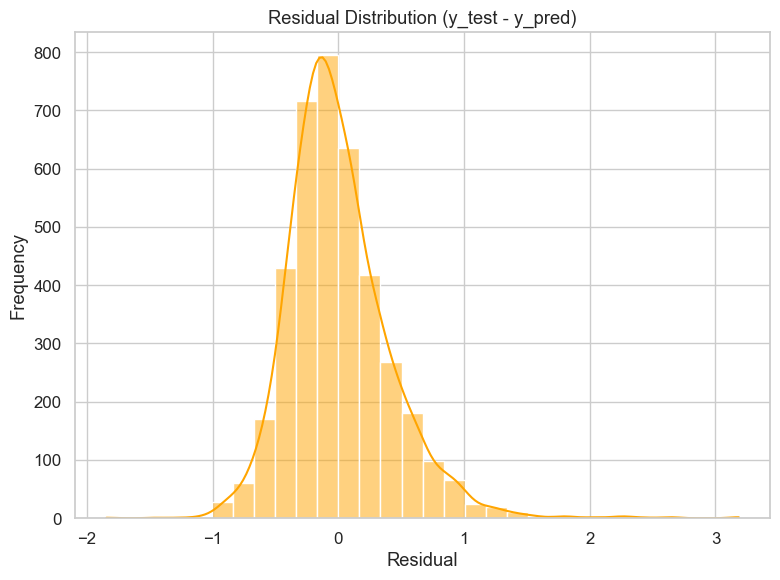

In [102]:
residuals = y_test - y_pred_lgbm

plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True, color='orange')
plt.title('Residual Distribution (y_test - y_pred)')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

##### 3. Feature Importance Plot

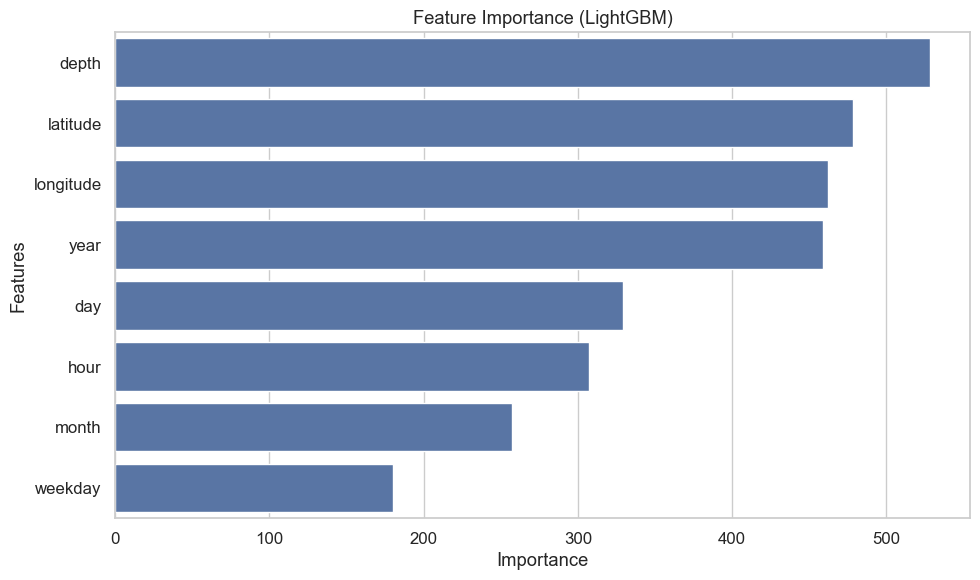

In [103]:
import numpy as np

# Get feature importances
importances = lgbm.feature_importances_
features = X.columns

# Sort
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=features[indices])
plt.title('Feature Importance (LightGBM)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

##### 4. Cross-Validation for LightGBM

In [107]:
from sklearn.model_selection import cross_val_score, KFold

# Suppress logs
lgbm = LGBMRegressor(random_state=42, verbosity=-1)

# Creating K-Fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# R² Scores
r2_scores = cross_val_score(lgbm, X, y, scoring='r2', cv=cv)
print("Cross-Validation R² Scores:", r2_scores)
print("Mean R² Score:", r2_scores.mean())
print("Standard Deviation:", r2_scores.std())

# MSE Scores
mse_scores = cross_val_score(lgbm, X, y, scoring='neg_mean_squared_error', cv=cv)
mse_scores = -mse_scores  # converting to positive values
print("\nCross-Validation MSE Scores:", mse_scores)
print("Mean MSE:", mse_scores.mean())
print("Standard Deviation:", mse_scores.std())

Cross-Validation R² Scores: [0.23141056 0.23406545 0.25331048 0.22356575 0.23854912]
Mean R² Score: 0.23618027020836915
Standard Deviation: 0.009852961435270124

Cross-Validation MSE Scores: [0.16849641 0.1788201  0.18047921 0.17387089 0.1583308 ]
Mean MSE: 0.17199948156906764
Standard Deviation: 0.00801290249688929


### **Interpretation:**

#### **R² Score:**

* **Mean R² Score**: `0.2362`
  → This means the model explains \~23.6% of the variance in earthquake magnitude predictions on average across all folds.
* **Std. Dev**: `0.0099`
  → Very low variance! The model is **consistent** across folds.

#### **MSE:**

* **Mean MSE**: `0.1720`
  → A low value, indicating **less average error** between predicted and actual magnitudes.
* **Std. Dev**: `0.0080`
  → Again, **very stable performance**.


### Summary:
The model:
* Is consistent across different folds.
* Performs better than Random Forest, XGBoost, SVR, and Linear Regression in the tests.
* Has the best combination of **low error** and **good generalization**.